# Evaluating robustness
With parameter sets generated from multi-omics data and enzyme kinetic databases, RobustNet constructs an ensemble of stochastic kinetic models, where each sampled parameter set defines one realization of the metabolic system. These ensemble models represent uncertainty in metabolic parameters and are used to simulate metabolic responses to engineering interventions, typically enzyme expression perturbations, and to evaluate metabolic robustness, i.e., whether and how likely the metabolic system can maintain a physiologically meaningful steady state following perturbation. Simulations are performed using a [continuation-like method](https://pubmed.ncbi.nlm.nih.gov/24972370/) that directly solves steady-state sensitivity equations along the perturbation trajectory, thereby avoiding repeated and computationally expensive time-domain integrations from scratch after each perturbation step. 

## Simulating enzyme perturbations
Using the same *E. coli* model, assume that the parameter sampling procedure has already been completed and the returned samp_res stores sampled metabolite concentrations, enzyme concentrations, and kinetic parameters for ensemble model construction (see [Parameterizing the model](https://robustnet.readthedocs.io/en/latest/parameterize_model.html) for more details). The `evaluate_robustness` can then be used to simulate perturbations of specified enzyme(s). 

For example, a 10-fold overexpression of pyruvate dehydrogenase relative to its reference-state expression level can be simulated as follows:

In [1]:
metab_sets = samp_res.sampled_metabolite_concentrations
enz_sets = samp_res.sampled_enzyme_concentrations
kparam_sets = pd.concat(
    (samp_res.sampled_kinetic_parameters, metab_sets), 
    axis=1
)

model.load_parameter_sets(
    mconc_set=metab_sets,
    econc_set=enz_sets,
    kparam_set=kparam_sets
)
rob_res = model.evaluate_robustness(
    perturb_enzymes=['PDH'],
    fold_change=(1, 10),
    exclude_metabolites=None,
    n_steps=300,
    n_models=1000,
    n_jobs=100
)

INFO: Perturb enzyme PDH (1, 10)


<div class="alert alert-info">
<b>Note:</b> <br></br>
Sensitivities are not explicitly calculated for certain metabolites, such as end metabolites or metabolites that appear only in rate expressions as activators or inhibitors and do not participate directly as substrates or products in the stoichiometric network. Their concentrations are instead treated as regular kinetic parameters. To account for these metabolites, the input `kparam_set` should include both sampled kinetic parameter sets and sampled metabolite concentration sets corresponding to these metabolites.
</div> 

`exclude_metabolites` can be used to exclude metabolites from sensitivity analysis.

`n_steps` controls the number of integration steps used to solve the sensitivity equations. Larger perturbation ranges generally require higher `n_steps` values for improved numerical stability and smoother trajectories. Perturbation points can be either evenly spaced or logarithmically spaced by setting `log_spacing`.

The size of the ensemble used in robustness analysis is specified by `n_models`.

The robustness of the metabolic system can be evaluated from the probability of ensemble models remaining viable across the perturbation range, which can be visualized using:

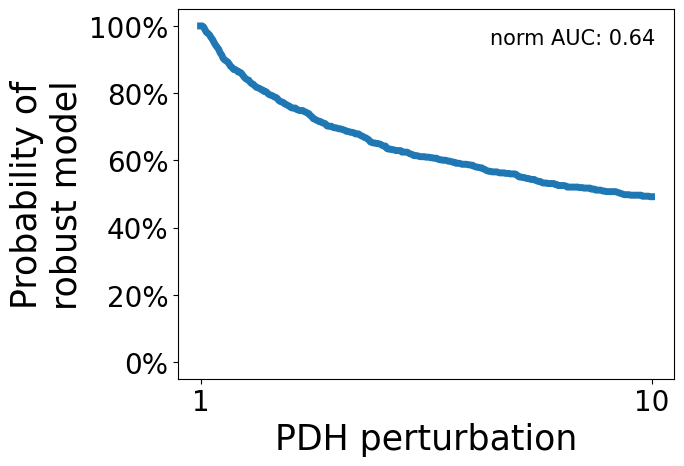

In [2]:
rob_res.robust_model_probability(out_dir=None, show_fig=True)

The robustness index (RI) provides a quantitative measure of system robustness and is defined as the normalized area under the survival probability curve across the specified perturbation range. RI ranges from 0 to 1, where lower values indicate a fragile metabolic system and higher values indicate stronger metabolic resilience against the specified perturbation.

In [3]:
print(f'Robustness index: {rob_res.robust_index:.3f}')

Robustness index: 0.644


Below demonstrates the robustness under a 2-fold downregulation of the same enzyme.

INFO: Perturb enzyme PDH (0.5, 1)


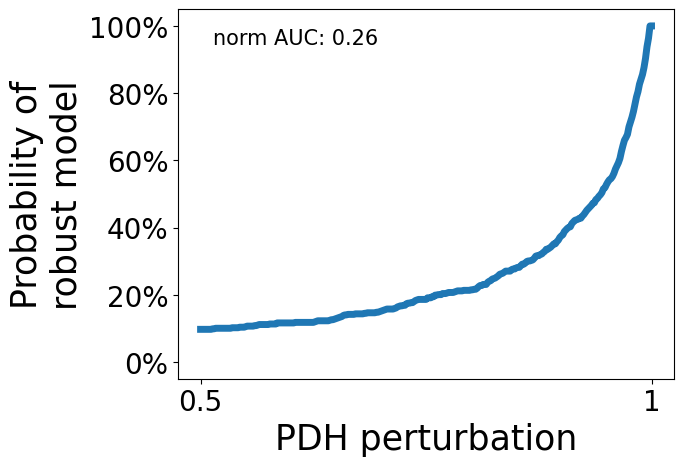

Robustness index: 0.257


In [4]:
rob_res = model.evaluate_robustness(
    perturb_enzymes=['PDH'],
    fold_change=(0.5, 1),
    exclude_metabolites=None,
    n_steps=300,
    n_models=1000,
    n_jobs=100
)
rob_res.robust_model_probability(out_dir=None, show_fig=True)
print(f'Robustness index: {rob_res.robust_index:.3f}')

The `fold_change` range must always include `1`, corresponding to the reference state. If `1` is used as one of the bounds, the perturbation is simulated only in a single direction, representing either upregulation or downregulation as shown above. If the fold-change interval spans across `1`, perturbations are simulated from the reference state toward both lower and upper bounds.

The following example demonstrates robustness analysis under up to 5-fold knockdown and 5-fold overexpression of the same enzyme.

INFO: Perturb enzyme PDH (0.2, 5)


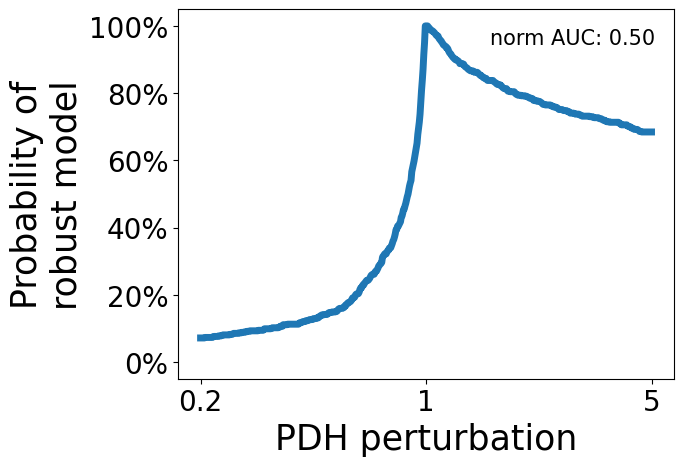

Robustness index: 0.499


In [5]:
rob_res = model.evaluate_robustness(
    perturb_enzymes=['PDH'],
    fold_change=(0.2, 5),
    exclude_metabolites=None,
    n_steps=300,
    n_models=1000,
    n_jobs=100
)
rob_res.robust_model_probability(out_dir=None, show_fig=True)
print(f'Robustness index: {rob_res.robust_index:.3f}')

Multiple-enzyme perturbations are also supported. For example, citrate synthase and 2-oxoglutarate dehydrogenase can be co-overexpressed with different fold-change ranges as follows:

INFO: Perturb enzyme GlcPTS (1, 2), PDH (1, 5)


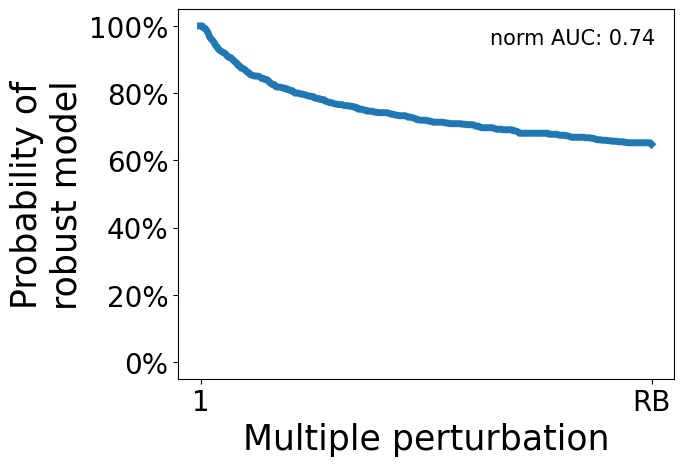

Robustness index: 0.742


In [6]:
rob_res = model.evaluate_robustness(
    perturb_enzymes=['GlcPTS', 'PDH'],
    fold_change={
        'GlcPTS': (1, 2), 
        'PDH': (1, 5)
    },
    exclude_metabolites=None,
    n_steps=300,
    n_models=1000,
    n_jobs=100
)
rob_res.robust_model_probability(out_dir=None, show_fig=True)
print(f'Robustness index: {rob_res.robust_index:.3f}')

Simultaneous knockdown and overexpression of different enzymes can also be simulated, as illustrated below.

INFO: Perturb enzyme GlcPTS (1, 2), PDH (1, 0.2)


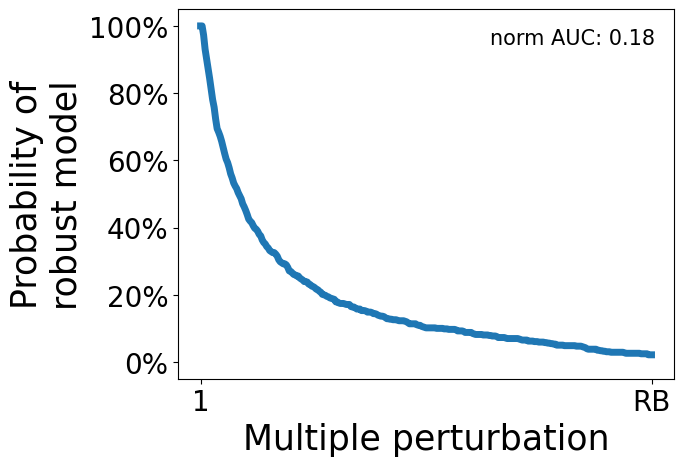

Robustness index: 0.181


In [7]:
rob_res = model.evaluate_robustness(
    perturb_enzymes=['GlcPTS', 'PDH'],
    fold_change={
        'GlcPTS': (1, 2), 
        'PDH': (1, 0.2)
    },
    exclude_metabolites=None,
    n_steps=300,
    n_models=1000,
    n_jobs=100
)
rob_res.robust_model_probability(out_dir=None, show_fig=True)
print(f'Robustness index: {rob_res.robust_index:.3f}')

In general, perturbations involving arbitrary combinations of enzymes and expression fold changes are supported.

## Inspecting metabolic responses
The simulation results can be further analyzed to investigate metabolic responses, including changes in steady-state metabolite concentrations and metabolic fluxes following perturbation.

Below, we demonstrate a 10-fold overexpression of GlcPTS as an example. 

In [8]:
rob_res = model.evaluate_robustness(
    perturb_enzymes=['GlcPTS'],
    fold_change=(1, 10),
    exclude_metabolites=None,
    n_steps=300,
    n_models=1000,
    n_jobs=100
)

INFO: Perturb enzyme GlcPTS (1, 10)


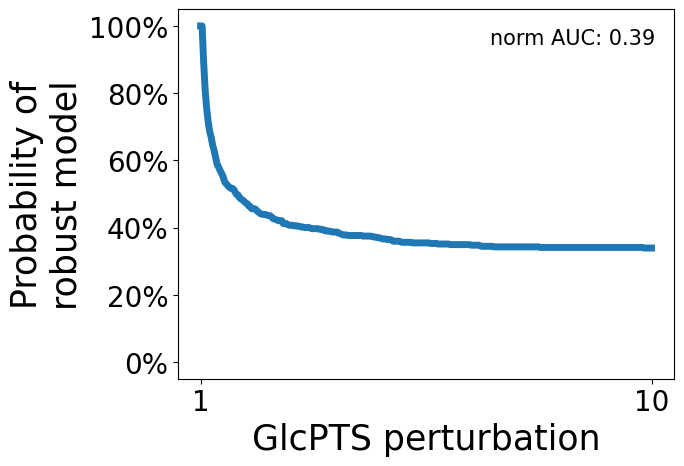

In [9]:
rob_res.robust_model_probability(out_dir=None, show_fig=True)

Metabolite responses can be visualized using the `metabolite_sensitivity` method (alias `bifurcation_diagram`).

We inspect the steady-state pyruvate concentration relative to its reference-state level in response to this perturbation.

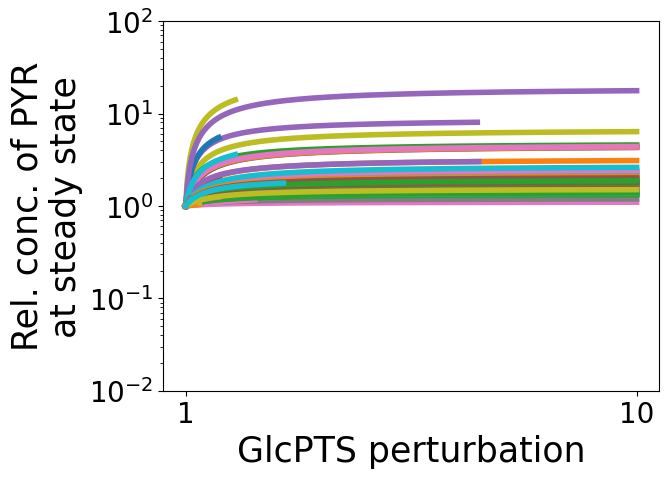

In [10]:
rob_res.metabolite_sensitivity(
    out_dir=None,
    kind='sample',
    metabolites=['PYR'],
    show_fig=True
)

Here metabolite response trajectories are visualized using sampled trajectories from ensemble models, where the number of displayed trajectories can be controlled through `n_sets`. Trajectories that terminate early indicate the occurrence of bifurcations or the emergence of non-physiological metabolite concentrations during perturbation. Alternatively, setting `kind` to "stats" displays a probability-density heatmap summarizing the responses across all models.

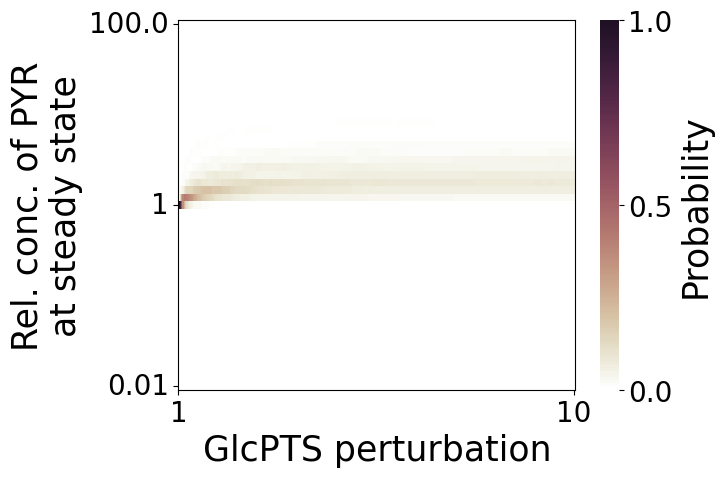

In [11]:
rob_res.metabolite_sensitivity(
    out_dir=None,
    kind='stats',
    metabolites=['PYR'],
    show_fig=True
)

The `metabolite_distribution` method visualizes the distribution of possible pyruvate concentrations throughout the perturbation process.

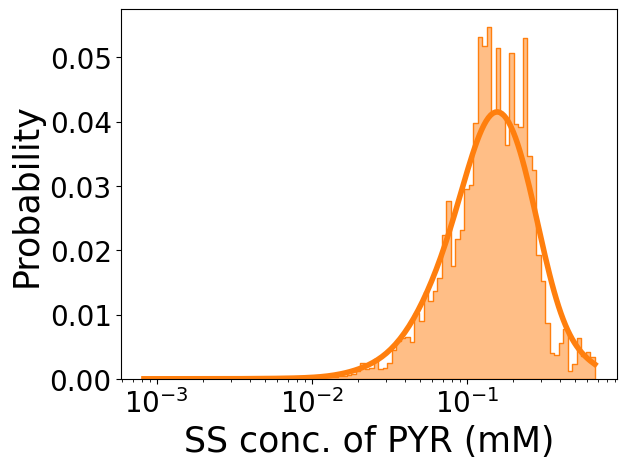

In [12]:
rob_res.metabolite_distribution(
    out_dir=None,
    metabolites=['PYR'],
    show_fig=True
)

In addition to metabolite concentrations, steady-state metabolic fluxes after perturbation can also be analyzed. The following example demonstrates how `flux_sensitivity` visualizes changes in pyruvate kinase flux relative to its reference-state value under perturbation.

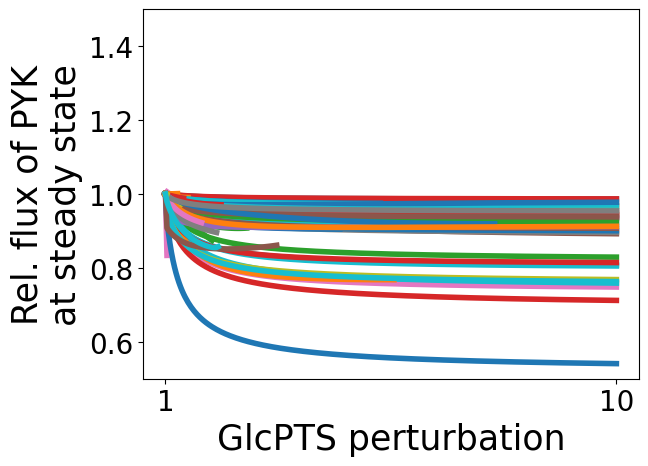

In [13]:
rob_res.flux_sensitivity(
    out_dir=None,
    kind='sample',
    reactions=['PYK'],
    show_fig=True
)

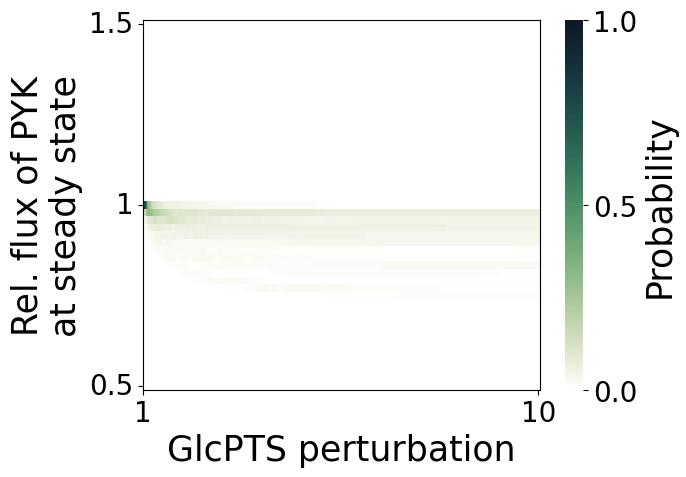

In [14]:
rob_res.flux_sensitivity(
    out_dir=None,
    kind='stats',
    reactions=['PYK'],
    show_fig=True
)

Similarly, the distribution of absolute flux values carried by the reaction during perturbation can be visualized as:

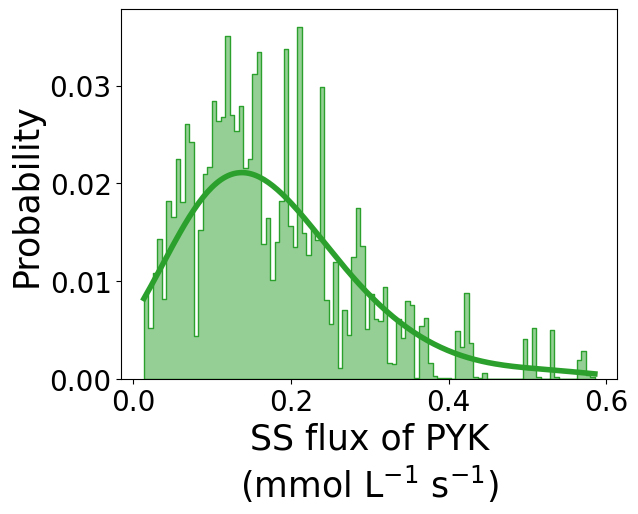

In [15]:
rob_res.flux_distribution(
    out_dir=None,
    reactions=['PYK'],
    show_fig=True
)